# Burn severity and erosion priority after the Vesuvius fire of August 2025

**The event.** A fire burned above Terzigno, on the south-east flank of Vesuvius, for four days from 8 August 2025. Copernicus EMS activation EMSR830 opened on 9 August. Press reports put the loss at about 500 hectares of pine and shrub.

**The question.** Which slopes should the park authority and the Campania civil protection treat first, before the autumn rains wash the ash off steep ground?

**The method**
1. Download Sentinel-2 images from before and after the fire.
2. Score burn severity per pixel with dNBR.
3. Add slope from the Copernicus DEM.
4. Rank 250 m cells by severe burn on steep ground.

**The outputs**
- A ranked table of cells.
- A GeoJSON of the flagged cells.
- A plain-language summary, written by code, not by a language model. The LLM version is bonus A.

**Data.** Microsoft Planetary Computer: Sentinel-2 L2A and Copernicus DEM GLO-30, processed locally. No account or API key.

**Run.** Python 3.12, then

```bash
pip install -r requirements.txt
pip install -e .
```

and run all cells. The README has the Colab variant.

## 1. Where, when and the rules

Every constant is set once, with its reason, in `src/burnsev/aoi.py`. Change one there and rerun.

| Setting | Value |
|---|---|
| **Box** | 14.35 to 14.50 E, 40.77 to 40.87 N: about 13 by 11 km around the cone and its south-east flank |
| **Pre-fire window** | 1 July to 7 August 2025 (scenes loaded from 1 June, to show the trend) |
| **Post-fire window** | 13 August to 15 September 2025 (scenes loaded to 15 October, to show the recovery) |
| **Severity** | dNBR in the five classes of Key and Benson (2006) |
| **Priority** | moderate or high severity (dNBR >= 0.27) on slope >= 23 degrees: the terrain term of USGS model M1 (Staley et al. 2017) |

Only the terrain term is computed. The full model also needs rainfall intensity and soil erodibility.

In [1]:
# Step 1. Every number a user might want to change lives in src/burnsev/aoi.py, with its reason next to it.
from burnsev import aoi

print("AOI (west, south, east, north):", aoi.BBOX)
print("Fire:", aoi.FIRE_START, "to", aoi.FIRE_END)
print("Pre-fire window: ", *aoi.PRE_WINDOW)
print("Post-fire window:", *aoi.POST_WINDOW)
print("Bands:", aoi.BANDS, "at", aoi.RESOLUTION, "m in", aoi.CRS)
print("Severe = dNBR >=", aoi.SEVERITY_CUT_DNBR, "->", aoi.SEVERE_CLASSES)
print("Steep  = slope >=", aoi.SLOPE_THRESHOLD_DEG, "deg; sensitivity at", aoi.SLOPE_SENSITIVITY_DEG)

# The libraries that did the geospatial work, for anyone comparing runs.
import odc.stac
import pyproj
import rasterio

print("odc-stac", odc.stac.__version__, "| rasterio", rasterio.__version__,
      "| GDAL", rasterio.__gdal_version__, "| PROJ", pyproj.proj_version_str)

AOI (west, south, east, north): (14.35, 40.77, 14.5, 40.87)
Fire: 2025-08-08 to 2025-08-12
Pre-fire window:  2025-07-01 2025-08-07
Post-fire window: 2025-08-13 2025-09-15
Bands: ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'SCL'] at 20 m in EPSG:32633
Severe = dNBR >= 0.27 -> ('moderate-low', 'moderate-high', 'high')
Steep  = slope >= 23.0 deg; sensitivity at (20.0, 23.0, 26.0)
odc-stac 0.5.3 | rasterio 1.5.1 | GDAL 3.12.4 | PROJ 9.8.1


## 2. Which scenes exist

A STAC search on Microsoft Planetary Computer returns the Sentinel-2 L2A products covering the box in each window, metadata only. The same search works on any STAC catalogue.

**The scene table** records date, satellite, orbit, cloud cover and processing version.

**Two choices**
- The 25 percent cloud ceiling is a coarse, tile-level filter. The real cleaning is per pixel in step 3.
- The offset is read per product, not assumed, because Sentinel-2 changed its number format in 2022.

In [2]:
# Step 2. Ask the catalogue which scenes exist over the box in each window. Metadata only, no pixels yet.
from burnsev import catalog

pre_items = catalog.search_scenes(aoi.BBOX, aoi.SERIES_START, aoi.PRE_WINDOW[1], aoi.MAX_CLOUD)
post_items = catalog.search_scenes(aoi.BBOX, aoi.POST_WINDOW[0], aoi.SERIES_END, aoi.MAX_CLOUD)
print(len(pre_items), "pre-fire and", len(post_items), "post-fire scenes under", aoi.MAX_CLOUD, "% cloud")

scenes = catalog.scene_table(pre_items + post_items)
scenes

32 pre-fire and 23 post-fire scenes under 25.0 % cloud


,id,date,satellite,orbit,tile,cloud_pct,baseline,boa_add_offset
0,S2C_MSIL2A_20250605T095051_R079_T33TVF_2025060...,2025-06-05,Sentinel-2C,79,33TVF,1.8,05.11,-1000
1,S2A_MSIL2A_20250607T095041_R079_T33TVF_2025060...,2025-06-07,Sentinel-2A,79,33TVF,0.0,05.11,-1000
2,S2A_MSIL2A_20250607T095041_R079_T33TVF_2025060...,2025-06-07,Sentinel-2A,79,33TVF,0.0,05.11,-1000
3,S2C_MSIL2A_20250608T100051_R122_T33TVF_2025060...,2025-06-08,Sentinel-2C,122,33TVF,9.5,05.11,-1000
4,S2B_MSIL2A_20250610T095029_R079_T33TVF_2025061...,2025-06-10,Sentinel-2B,79,33TVF,2.5,05.11,-1000
5,S2A_MSIL2A_20250610T100041_R122_T33TVF_2025061...,2025-06-10,Sentinel-2A,122,33TVF,2.4,05.11,-1000
6,S2B_MSIL2A_20250613T100029_R122_T33TVF_2025061...,2025-06-13,Sentinel-2B,122,33TVF,0.2,05.11,-1000
7,S2C_MSIL2A_20250615T095051_R079_T33TVF_2025061...,2025-06-15,Sentinel-2C,79,33TVF,0.6,05.11,-1000
8,S2A_MSIL2A_20250617T095051_R079_T33TVF_2025061...,2025-06-17,Sentinel-2A,79,33TVF,12.6,05.11,-1000
9,S2B_MSIL2A_20250620T095029_R079_T33TVF_2025062...,2025-06-20,Sentinel-2B,79,33TVF,1.5,05.11,-1000


**What the table shows**
- **55 products:** 32 pre-fire, 23 post-fire, all under 25 percent cloud.
- **Three satellites** (Sentinel-2A, 2B, 2C) on **two orbits** (79, 122) ten minutes apart, so some dates appear twice.
- **First post-fire scene:** 14 August, two days after containment.
- **Baseline 05.11 throughout.** Baseline 04.00 (January 2022) added 1000 to every stored value, so the offset is minus 1000, read from metadata.
- **7 June** was published twice, 90 minutes apart. Step 3 groups by solar day, so it counts once.
- **Cloud filter** on the returned metadata, in Python: this catalogue does not advertise the STAC query extension.

**Next.** Download the pixels of these 55 products, mask clouds per pixel, convert to reflectance.

## 3. Load the pixels and mask the clouds

**The cube.** odc-stac reads only the box from the band files of the 55 products, into one cube per band: shape (46, 560, 637) at 20 m in UTM zone 33.
- No reprojection: the files are already in UTM zone 33.
- The three 10 m bands are averaged to 20 m, the native size of B8A and B12.
- Same-day products are fused, first valid pixel wins.
- The download is cached. Everything after it is recomputed each run.

![One stack per band](docs/figures/cube.png)

**Three steps on the raw numbers**
- **Reflectance.** (DN + BOA_ADD_OFFSET) / 10,000. The offset is minus 1,000 for all 55 products (baseline 05.11).
- **Cloud mask** from SCL: no data, saturated, cloud shadow, cloud, thin cirrus and snow are blanked. Water and dark pixels are kept: SCL is built for the atmospheric correction, [not as a land cover map](https://sentinel.esa.int/en/web/sentinel/user-guides/sentinel-2-msi/processing-levels/level-2), and on 19 August it labels a quarter of the burn as water.
- **Quality.** The usable pixel share per date is kept.

{'y': 560, 'x': 637, 'time': 46} | EPSG 32633 | reflectance cube 394 MB


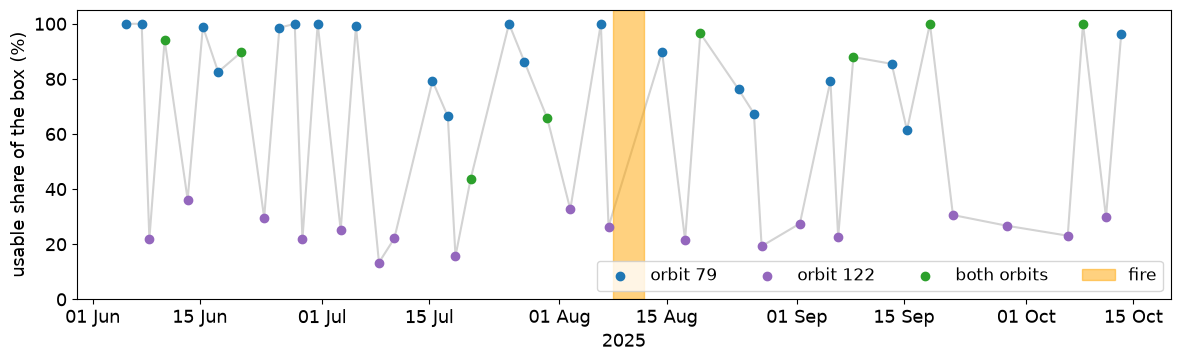

In [3]:
# Step 3. Download the pixels once (cached), then mask clouds with SCL and convert to reflectance.
from burnsev import ingest, plots

cube_file = ingest.cache_path("s2_dn_20m")
dn = ingest.load_cached(cube_file)
if dn is None:
    dn = ingest.load_cube(pre_items + post_items)  # digital numbers, one time step per solar day
    ingest.save_cube(dn, cube_file)

refl = ingest.mask_and_scale(dn, catalog.offsets_by_day(pre_items + post_items))
print(dict(refl.sizes), "| EPSG", refl.odc.crs.epsg, "| reflectance cube", round(refl.nbytes / 1e6), "MB")
fig = plots.usable_share(refl, catalog.orbits_by_day(pre_items + post_items), (aoi.FIRE_START, aoi.FIRE_END))

**What the run shows**
- **46 dates** from 55 products: 27 pre-fire, 19 post-fire. Ten pre-fire and four post-fire dates see the whole box.
- **Two orbits.** Orbit 79 covers the whole box; its dips on 20 July and 15 September are cloud. Orbit 122 sees only the western fifth, 20 to 35 percent on every date.
- **No date is dropped.** Step 5 takes medians per pixel over the available dates. The east is seen only by orbit 79.

**Next.** True colour before and after, one stretch for both dates.

## 4. Look before and after

**Dates.** 6 August, two days before the reported start, and 14 August, two days after containment, the first fully clear date over the burn.

**Stretch.** Each band is stretched between its 2nd and 98th percentile (the QGIS default): land reflectance sits mostly between 0.02 and 0.30, so the full 0 to 1 range would look almost black.
- The bounds come from the pre-fire image and are reused on the post-fire one, so the pair stays comparable.
- Masked pixels are light grey. The stretch is display only.

**Second row.** Short-wave infrared: B12 as red, B8A as green, B04 as blue. Healthy vegetation is bright in the near infrared and dark in the short-wave infrared, so it shows green. Burned ground is the opposite and shows dark red. That is the contrast the burn index in step 5 turns into a number.

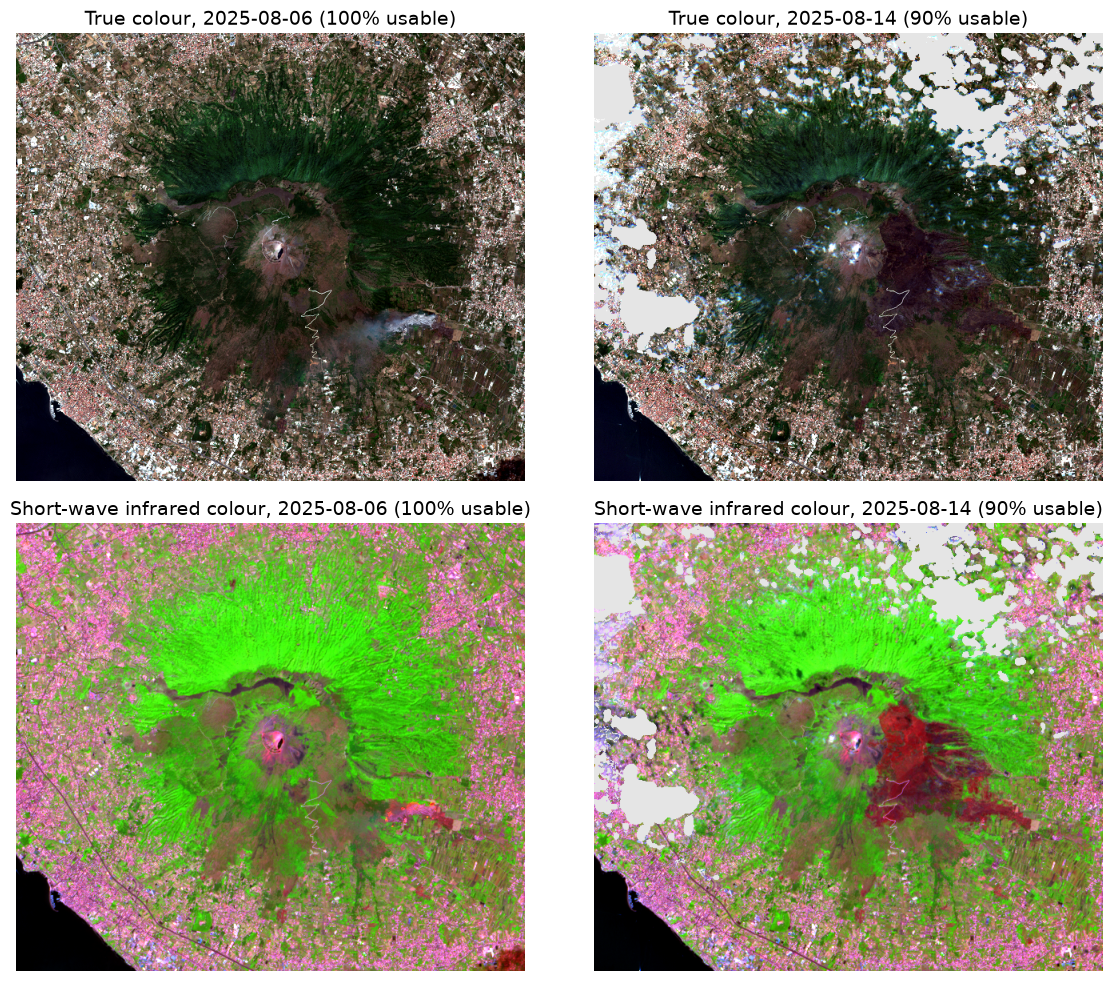

In [4]:
# Step 4. The clearest dates closest to the fire, in true colour and in short-wave infrared colour.
pre_day, post_day = "2025-08-06", "2025-08-14"
fig = plots.before_after(refl, pre_day, post_day)

**What the pictures show**
- **The burn** is a dark brown patch on the south-east flank, dark red in short-wave infrared against bright green forest.
- **6 August.** A smoke plume and a small dark red patch sit at the eastern edge of the future burn. Mean NBR inside the burn on that date is 0.39, close to the 0.43 of 25 July: the main fire came later, and one early date does not shift the pre-fire median.
- **14 August.** The clouds sit north of the cone, outside the burn, every burn pixel usable. 19 August, 24 August and 8 September are cloudier over the burn, hence this pair. 18 September is the next fully clear date.
- **Ash as water.** On 19 August the scene classification labels a quarter of the burn as water: fresh ash is as dark as water. Water stays out of the mask so a burn scar is not discarded as a lake.

**Next.** Turn the contrast into a number per pixel: NBR on each date, medians before and after, dNBR as their difference.

## 5. Composites, NBR and dNBR

**NBR** = (B8A - B12) / (B8A + B12): high for live vegetation, low for bare or charred ground. The sum cancels brightness differences between dates. Computed per pixel, per date.

**Median composites.** Each window becomes one median per pixel, not a mean: one odd date (haze, a missed cloud edge, the small fire of 6 August) cannot move it.

**Windows: 1 July to 7 August before, 13 August to 15 September after.** A median summarises a window well only when the window is stable. Before the fire, NBR inside the future burn slides through June while the unburned reference stays flat, so the pre-fire window starts in July. After the fire, recovery starts within weeks as ash washes off and grass returns, so the post-fire window is one month. That is the initial-assessment timing of Key and Benson (2006), the period Veraverbeke et al. (2010) found best for Mediterranean pine and shrub before regrowth pulls dNBR down, and the 30 days at which EFFIS computes severity. Scenes are loaded from 1 June to 15 October so the plot shows both trends.

**NDVI** = (B8A - B04) / (B8A + B04), the second index. NBR reacts to char and ash through the short-wave infrared; NDVI reacts to green leaf through the red band, the cover that holds the soil. It is plotted next to NBR and carried to the grid in step 9 as the green cover left after the fire.

**dNBR** = median before minus median after. Positive means vegetation lost; step 6 classifies it.

The cell prints the source of the index functions, so the formula on this page is the code that ran, and counts the usable observations behind each pixel.

```python
def nbr(ds: xr.Dataset) -> xr.DataArray:
    """Normalised Burn Ratio, (B8A - B12) / (B8A + B12), per pixel and date.

    Healthy vegetation is bright in the near infrared (B8A) and dark in the short-wave
    infrared (B12), so NBR is high. Burned ground is the reverse, so NBR drops after a fire.
    """
    return normalised_difference(ds["B8A"], ds["B12"]).rename("NBR")
```

```python
def ndvi(ds: xr.Dataset) -> xr.DataArray:
    """Normalised Difference Vegetation Index, (B8A - B04) / (B8A + B04), per pixel and date.

    NBR reacts to char and ash through the short-wave infrared; NDVI reacts to green leaf
    through the red band. After a fire it measures the cover left to hold the soil. B8A (the
    narrow near-infrared band) is used instead of the 10 m B08 so both indices share the 20 m grid.
    """
    return normalised_difference(ds["B8A"], ds["B04"]).rename("NDVI")
```

```python
def dnbr(nbr_da: xr.DataArray, pre: tuple[str, str], post: tuple[str, str]) -> xr.DataArray:
    """dNBR = median NBR before the fire minus median NBR after it. Positive means burned.

    Differencing removes what the two composites share (soil colour, terrain, the sensor)
    and keeps the change, which is what the severity classes are defined on.
    """
    return (window_median(nbr_da, *pre) - window_median(nbr_da, *post)).rename("dNBR")
```

pre-fire: usable observations per pixel, min 2, median 7, max 14
post-fire: usable observations per pixel, min 1, median 7, max 12


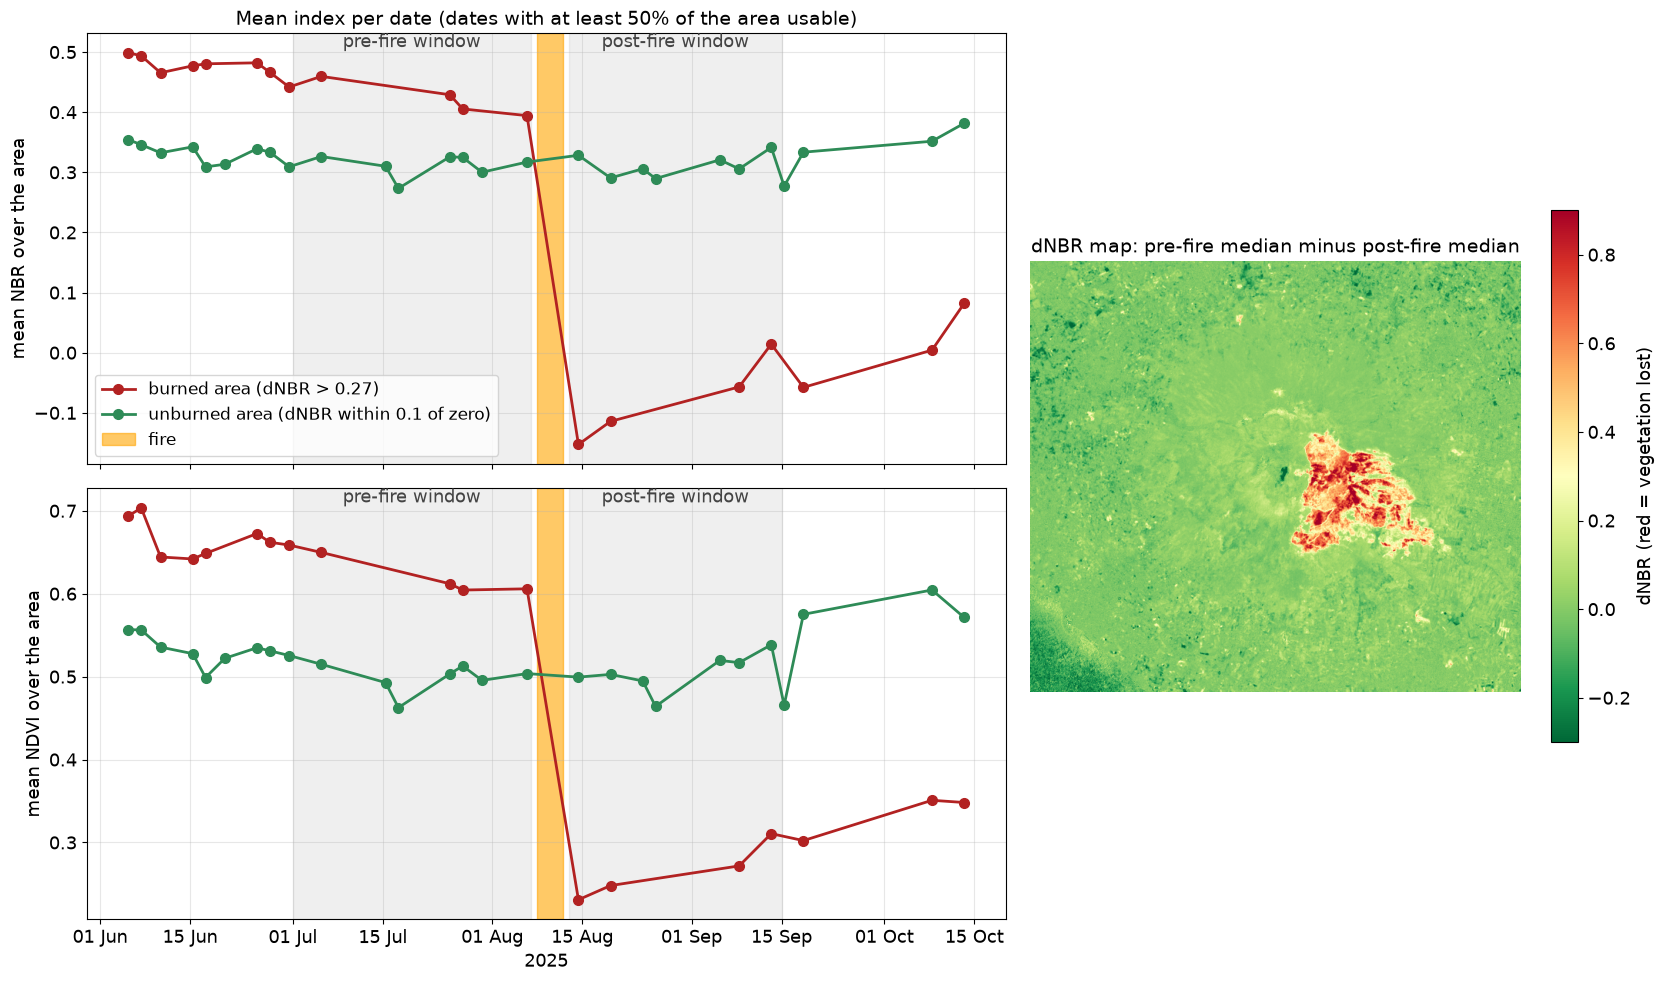

In [5]:
# Step 5. NBR and NDVI per pixel and date, the median of each window, and dNBR = before minus after.
import inspect

from IPython.display import Markdown, display

from burnsev import indices


def show(fn):
    """The source of a function, shown next to the cell that calls it."""
    return Markdown(f"```python\n{inspect.getsource(fn)}```")


display(show(indices.nbr), show(indices.ndvi), show(indices.dnbr))
nbr = indices.nbr(refl)
ndvi = indices.ndvi(refl)
dnbr = indices.dnbr(nbr, aoi.PRE_WINDOW, aoi.POST_WINDOW)
for label, window in (("pre-fire", aoi.PRE_WINDOW), ("post-fire", aoi.POST_WINDOW)):
    n = indices.window_count(nbr, *window)
    print(f"{label}: usable observations per pixel, min {int(n.min())}, median {int(n.median())}, max {int(n.max())}")

burn = dnbr > aoi.SEVERITY_CUT_DNBR
fire = (aoi.FIRE_START, aoi.FIRE_END)
fig = plots.index_history_and_dnbr(nbr, ndvi, dnbr, burn, aoi.PRE_WINDOW, aoi.POST_WINDOW, fire)

**What the run shows**
- Usable observations per pixel: pre-fire min 2, median 7; post-fire min 1, median 7.
- Inside the burn (dNBR > 0.27, 591 ha), median NBR falls from 0.44 before the fire to -0.10 after; by 13 October it is back to 0.08. The unburned area stays at 0.33 before and 0.32 after, so the drop is the fire, not the season.
- Pre-fire window: the June points sit above the July shading. NBR inside the future burn slides from 0.50 on 5 June to 0.39 on 6 August. A June start would give 637 ha of severe burn instead of 591.
- Post-fire window: recovery starts within weeks, so the window ends on 15 September. A median to 15 October would give 564 ha with a high class of 91 ha instead of 149 ha; the first clear observation per pixel gives 628 ha and 204 ha.
- dNBR inside the burn: median 0.51, 90th percentile 0.79.
- NDVI tells the same story from the red band: median 0.62 before the fire, 0.24 after inside the burn; 0.52 and 0.56 over the unburned area. By 13 October the burn is back to a mean of 0.35, about half its green cover.

**Next.** Classes and hectares per class.

## 6. Severity classes and areas

dNBR is cut into the five classes of Key and Benson (2006): unburned below 0.10, low to 0.27, moderate-low to 0.44, moderate-high to 0.66, high above. The breaks are the published ones, the same set EFFIS uses; they were calibrated in North American forests, and that is stated as a limitation rather than tuned here. A pixel exactly on a break goes to the upper class.

**One fire, one perimeter.** Outside the fire, hundreds of small patches across the box also pass the breaks: fields harvested or mown between July and September, small unrelated fires, cloud edges missed by the mask. dNBR registers the change, not its cause, and pre-fire NDVI does not separate them (they were green too). The rule is spatial: keep the largest connected patch of burned pixels, diagonals included. The pixels left out are drawn grey on the map and counted in the table, so nothing is hidden.

Area per class is the pixel count times 0.04 ha (one 20 m pixel). "Burned" means every class from low upwards; "severe" means moderate-low and above, the cut the decision rule uses.

```python
def severity_class(dnbr_da: xr.DataArray) -> xr.DataArray:
    """Class code per pixel from dNBR, using the breaks in ``aoi.SEVERITY_CLASSES``.

    0 = unburned, 1 = low, 2 = moderate-low, 3 = moderate-high, 4 = high; 255 = no data.
    A pixel exactly on a break goes to the upper class (0.27 is moderate-low).
    """
    breaks = [low for _, low, _ in aoi.SEVERITY_CLASSES[1:]]  # 0.10, 0.27, 0.44, 0.66
    codes = np.digitize(dnbr_da.values, breaks).astype("uint8")
    codes[np.isnan(dnbr_da.values)] = 255
    return dnbr_da.copy(data=codes).rename("severity")
```

```python
def main_fire(sev: xr.DataArray) -> xr.DataArray:
    """True on the largest connected patch of burned pixels (class low or above).

    Connected includes diagonal neighbours. The small patches elsewhere in the box also pass
    the dNBR breaks, but they are harvested fields, other small fires and cloud edges, not this
    fire; one fire is one perimeter.
    """
    burned = (sev.values >= 1) & (sev.values != 255)
    labels, n = ndimage.label(burned, structure=np.ones((3, 3), dtype=bool))
    if n == 0:
        return sev.copy(data=np.zeros(sev.shape, dtype=bool)).rename("main_fire")
    sizes = ndimage.sum(burned, labels, range(1, n + 1))
    return sev.copy(data=labels == int(np.argmax(sizes)) + 1).rename("main_fire")
```

whole box: burned (low and above) 955 ha, severe (moderate-low and above) 591 ha
main fire: burned (low and above) 737 ha, severe (moderate-low and above) 576 ha


,dNBR range,whole box (ha),main fire (ha)
class,,,
unburned,below 0.10,13313.3,
low,0.10 to 0.27,364.1,160.9
moderate-low,0.27 to 0.44,205.4,191.2
moderate-high,0.44 to 0.66,237.2,236.4
high,above 0.66,148.7,148.7


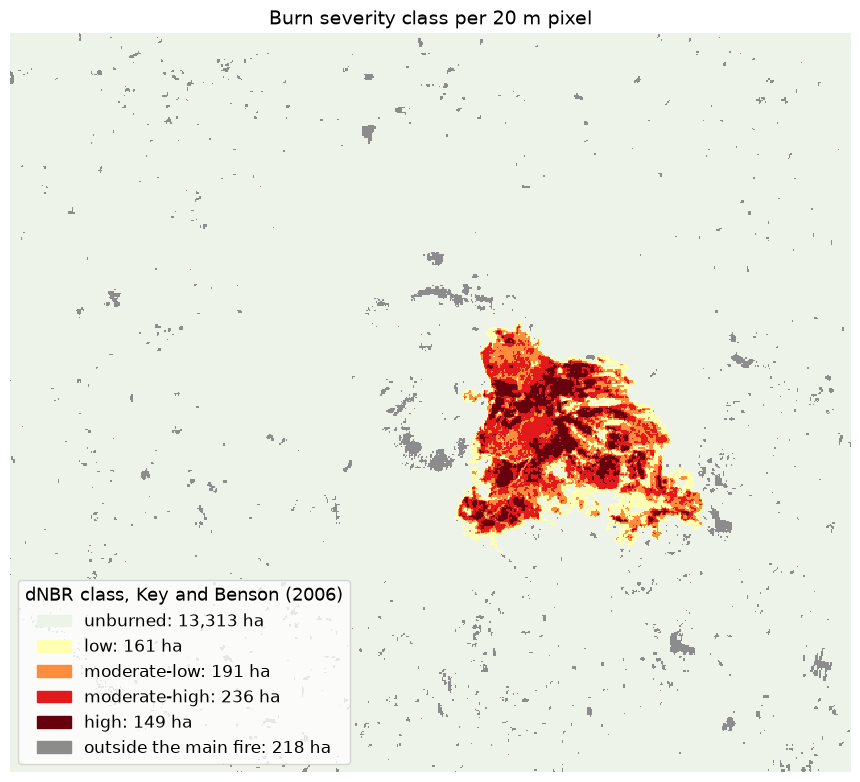

In [6]:
# Step 6. Cut dNBR into the Key and Benson classes, keep the main fire, count hectares per class.
import pandas as pd

display(show(indices.severity_class), show(indices.main_fire))
severity_all = indices.severity_class(dnbr)
fire_mask = indices.main_fire(severity_all)
severity = severity_all.where(fire_mask | (severity_all == 255), 0).astype("uint8")
outside = (severity_all >= 1) & (severity_all != 255) & ~fire_mask

names = [name for name, _, _ in aoi.SEVERITY_CLASSES]
areas_all = indices.area_by_class(severity_all, aoi.RESOLUTION)
areas = indices.area_by_class(severity, aoi.RESOLUTION)
table = pd.DataFrame(
    {"dNBR range": ["below 0.10" if lo < -1 else f"above {lo:.2f}" if hi > 1 else f"{lo:.2f} to {hi:.2f}"
                    for _, lo, hi in aoi.SEVERITY_CLASSES],
     "whole box (ha)": [areas_all.get(n, 0.0) for n in names],
     "main fire (ha)": [areas.get(n, 0.0) if n != "unburned" else "" for n in names]},
    index=names,
).rename_axis("class")
for col in ("whole box (ha)", "main fire (ha)"):
    burned = table[col].iloc[1:].astype(float).sum()
    severe = table[col].loc[list(aoi.SEVERE_CLASSES)].astype(float).sum()
    print(f"{col[:-5]}: burned (low and above) {burned:,.0f} ha, severe (moderate-low and above) {severe:,.0f} ha")
fig = plots.severity_map(severity, areas, excluded=outside)
table

**What the run shows**

| | whole box | main fire |
|---|---|---|
| burned (low and above) | 955 ha | 737 ha |
| severe (moderate-low and above) | 591 ha | 576 ha |

- **Main fire.** 737 ha in one patch on the south-east flank, 576 ha of it severe. Moderate-high and high are almost entirely inside it (236 of 237 ha, 149 of 149 ha).
- **Left out.** 218 ha in 957 patches, the largest 9.2 ha, 928 of them under 1 ha. Most of it is low class: the scattered change is mild, the fire is not.
- **NDVI agrees with the classes.** Post-fire median NDVI inside the main fire falls with severity: 0.43 in low, 0.29 in moderate-low, 0.25 in moderate-high, 0.16 in high. The classes come from the short-wave infrared, NDVI from the red band, so the order is not built in.
- **Against the press.** Around 500 ha were reported during the fire; 737 ha burned and 576 ha severe from the images. The EFFIS perimeter in step 7 is the independent check.

**Next.** Compare the main fire with the EFFIS burnt-area perimeter.

## 7. Check against the EFFIS perimeter

EFFIS, the European Forest Fire Information System of the Joint Research Centre, publishes a burnt-area polygon per fire. It maps fires from MODIS and refines the outline with Sentinel-2 at 20 m: a different team and method on the same satellite family, so agreement tests the processing, not the sensor. It is a reference, not ground truth: an extent without severity.

- **Which polygons.** Every EFFIS fire that started between the start of the pre-fire window and the start of the post-fire window, since anything burned in that span shows up as change in dNBR. Our map cannot separate fires that touch, so the comparison is against their union.
- **A fixed copy.** Fetched once from the EFFIS web feature service and saved in `data/reference/` with the fetch date. EFFIS revises its polygons and its service is sometimes down; `refresh=True` fetches again.
- **Same grid.** The polygons are reprojected to UTM 33N and rasterised on the 20 m grid, a pixel counting when its centre is inside, then compared pixel by pixel with the main fire.
- **Score.** Intersection over union (IoU): pixels burned in both maps divided by pixels burned in either. 1 means identical maps, 0 means no overlap.

```python
def rasterise(fires: list[dict], like: xr.DataArray, crs: str = "EPSG:4326") -> xr.DataArray:
    """True on every pixel of ``like``'s grid whose centre falls inside one of the polygons.

    The polygons are reprojected from ``crs`` to the grid's CRS first, so the comparison is
    pixel against pixel on the same 20 m grid.
    """
    shapes = gpd.GeoDataFrame.from_features(fires, crs=crs).to_crs(like.rio.crs).geometry
    if len(shapes) == 0:
        return like.copy(data=np.zeros(like.shape, dtype=bool)).rename("reference")
    burned = features.rasterize(
        ((geom, 1) for geom in shapes),
        out_shape=like.shape,
        transform=like.rio.transform(),
        fill=0,
        dtype="uint8",
    )
    return like.copy(data=burned.astype(bool)).rename("reference")
```

```python
def agreement(ours: xr.DataArray, ref: xr.DataArray, pixel_m: float) -> dict[str, float]:
    """Hectares burned in each map, in both, in only one, and intersection over union.

    IoU = both / (ours or reference): 1 when the two maps are identical, 0 when they do not touch.
    """
    a, b = ours.values.astype(bool), ref.values.astype(bool)
    ha = pixel_m * pixel_m / 10_000
    union = int((a | b).sum())
    return {
        "ours_ha": round(float(a.sum()) * ha, 1),
        "reference_ha": round(float(b.sum()) * ha, 1),
        "both_ha": round(float((a & b).sum()) * ha, 1),
        "only_ours_ha": round(float((a & ~b).sum()) * ha, 1),
        "only_reference_ha": round(float((~a & b).sum()) * ha, 1),
        "iou": round(float((a & b).sum()) / union, 2) if union else float("nan"),
    }
```

EFFIS polygons fetched 2026-09-23: 12 fires in the box since 2016, 3 in the windows
ours_ha: 737.1 | reference_ha: 753.2 | both_ha: 685.8 | only_ours_ha: 51.3 | only_reference_ha: 67.4 | iou: 0.85


,municipality,start,end,hectares
EFFIS id,,,,
278540,Terzigno,2025-08-07,2025-08-09,681.0
278005,Ottaviano,2025-08-09,2025-08-10,37.0
276273,Terzigno,2025-08-05,2025-08-06,36.0


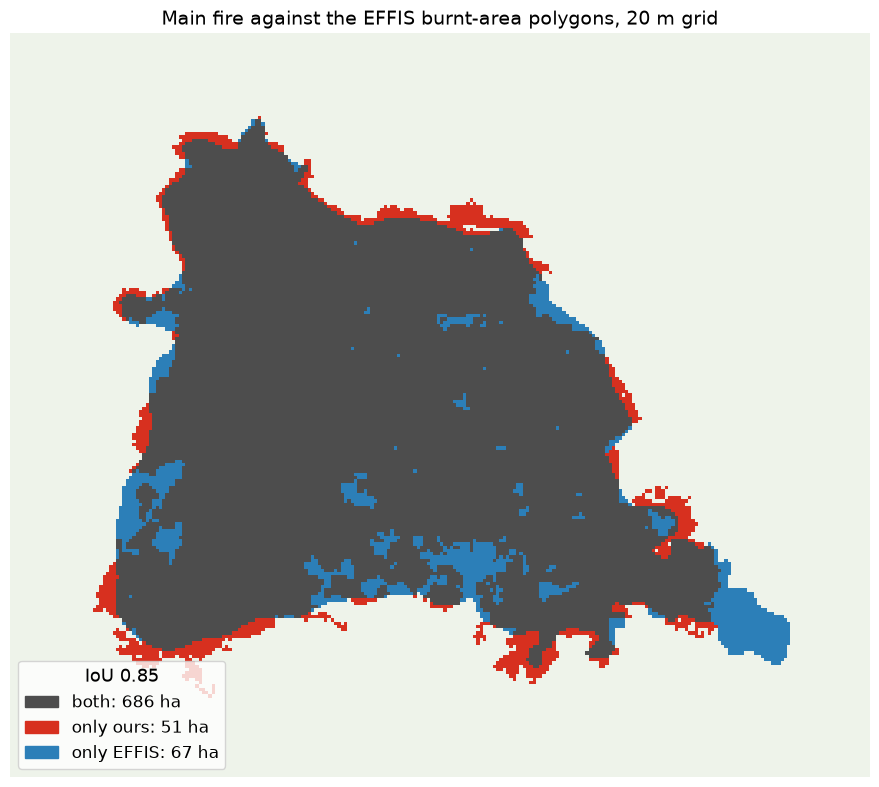

In [7]:
# Step 7. Compare the main fire with the EFFIS burnt-area polygons on the same 20 m grid.
from burnsev import reference

display(show(reference.rasterise), show(reference.agreement))
effis = reference.load_effis(aoi.BBOX)
fires = reference.fires_between(effis, aoi.PRE_WINDOW[0], aoi.POST_WINDOW[0])
effis_mask = reference.rasterise(fires, dnbr)
scores = reference.agreement(fire_mask, effis_mask, aoi.RESOLUTION)

print(f"EFFIS polygons fetched {effis['fetched']}: {len(effis['features'])} fires in the box since 2016, {len(fires)} in the windows")
print(" | ".join(f"{k}: {v}" for k, v in scores.items()))
fig = plots.agreement_map(fire_mask, effis_mask, scores)
reference.fire_table(fires)

**What the run shows**

| | hectares |
|---|---|
| EFFIS, three fires of 5 to 10 August | 753 |
| main fire, this notebook | 737 |
| burned in both | 686 |
| only in ours | 51 |
| only in EFFIS | 67 |

- **IoU 0.85.** 91 % of the EFFIS area lies in our main fire, and 93 % of our main fire lies in EFFIS.
- **Only in ours: a rim.** A median of 40 m, two pixels, outside the EFFIS edge; 41 of the 51 ha are in the low class. The edge of a burn is gradual, and the two methods draw the line in slightly different places.
- **Only in EFFIS: little change on the ground.** Median dNBR 0.06, under the 0.10 break of the low class. 16 ha are unburned islands inside our outline that the EFFIS polygon encloses. 17 ha belong to the small fire of 5 to 6 August: 7 ha that step 6 left outside the main fire, 10 ha whose change stays under the low break.
- **Fire date.** EFFIS dates the main fire from 7 August; reports give the evening of 8 August. The only image between 6 and 14 August, on 7 August, covers the west of the box and none of the fire, so no number here depends on which date is right.

**Next.** Slope from the Copernicus DEM, the terrain half of the erosion question.

## 8. Terrain: DEM and slope

**Why slope.** The erosion rule in step 9 follows the M1 model of Staley et al. (2017): the share of an area that is both burned at moderate or high severity and steeper than 23°. Sensitivity at 20° and 26°.

**DEM.** Copernicus DEM GLO-30 from the same Planetary Computer catalogue: one tile, one arc second, about 23 m east-west and 31 m north-south here. odc-stac warps it on this machine onto the cube's own grid, so every elevation value sits on a Sentinel-2 pixel. Bilinear resampling, because elevation is continuous.

**Slope.** Horn's 3 by 3 method in degrees, the GDAL and QGIS default. Jones (1998) ranks it second of eight algorithms, a small margin behind Zevenbergen and Thorne; Skidmore (1989) finds it among the most reliable.

**Order of operations.** Grohmann (2015) shows that slope should be derived on the finer grid and resampled afterwards, since resampling elevation first smooths relief. That concerns coarsening; here the DEM goes from 30 m to 20 m. Both orders were run on this fire: 128 ha severe and steep when resampling first, 125 ha when deriving on the native grid, a median difference of 0.0° per pixel. The simpler order is kept.

```python
def slope_degrees(dem: xr.DataArray, pixel_m: float) -> xr.DataArray:
    """Slope in degrees with Horn's 3 by 3 method, the one GDAL and QGIS use.

    Each gradient is a weighted difference across the eight neighbours, which smooths noise
    better than a two-pixel difference. The one-pixel border has no full neighbourhood and
    is left NaN.
    """
    z = dem.values.astype("float64")
    a, b, c = z[:-2, :-2], z[:-2, 1:-1], z[:-2, 2:]  # row above
    d, f = z[1:-1, :-2], z[1:-1, 2:]  # same row, left and right
    g, h, i = z[2:, :-2], z[2:, 1:-1], z[2:, 2:]  # row below
    dz_dx = ((c + 2 * f + i) - (a + 2 * d + g)) / (8 * pixel_m)
    dz_dy = ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * pixel_m)
    out = np.full(z.shape, np.nan, dtype="float32")
    out[1:-1, 1:-1] = np.degrees(np.arctan(np.hypot(dz_dx, dz_dy)))
    return dem.copy(data=out).rename("slope")
```

elevation in the box 0 to 1286 m | slope in the main fire: 10th percentile 6.3°, median 15.7°, 90th percentile 27.9°


,main fire at or above (ha),severe at or above (ha),share of severe (%)
slope threshold,,,
20°,232.0,190.0,33.0
23°,157.0,128.0,22.0
26°,99.0,80.0,14.0


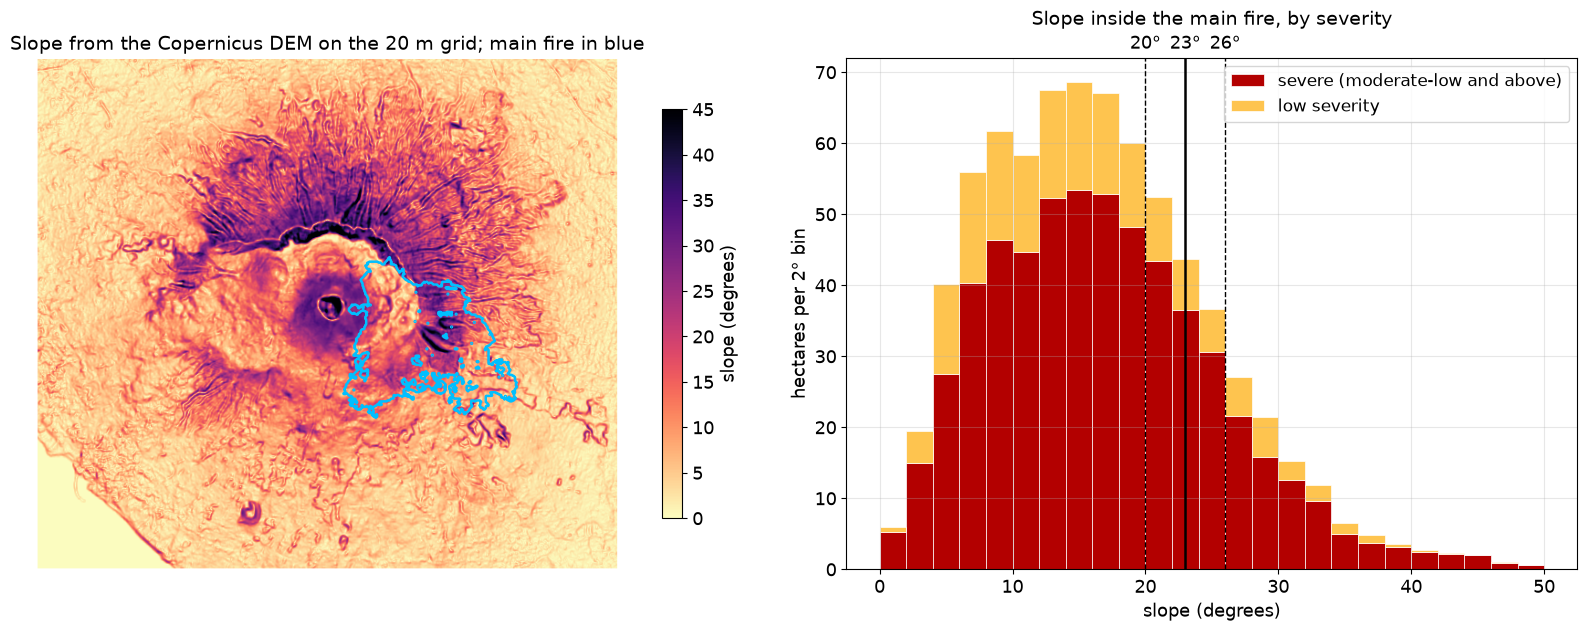

In [8]:
# Step 8. Copernicus DEM on the cube grid, slope in degrees, the slopes inside the main fire.
from burnsev import terrain

display(show(terrain.slope_degrees))
dem = terrain.load_dem(catalog.search_dem(aoi.BBOX), dnbr)
slope = terrain.slope_degrees(dem, aoi.RESOLUTION)

severe_codes = [code for code, name in indices.class_names().items() if name in aoi.SEVERE_CLASSES]
severe = fire_mask & severity.isin(severe_codes)
ha = aoi.RESOLUTION**2 / 10_000
low, mid, high = (float(v) for v in slope.where(fire_mask).quantile([0.1, 0.5, 0.9]))
print(f"elevation in the box {float(dem.min()):.0f} to {float(dem.max()):.0f} m | "
      f"slope in the main fire: 10th percentile {low:.1f}°, median {mid:.1f}°, 90th percentile {high:.1f}°")

steep = pd.DataFrame(
    {f"{t:.0f}°": {"main fire at or above (ha)": float((fire_mask & (slope >= t)).sum()) * ha,
                   "severe at or above (ha)": float((severe & (slope >= t)).sum()) * ha,
                   "share of severe (%)": 100 * float((severe & (slope >= t)).sum()) / float(severe.sum())}
     for t in aoi.SLOPE_SENSITIVITY_DEG}
).T.round(0).rename_axis("slope threshold")
fig = plots.slope_and_fire(slope, fire_mask, severe, aoi.SLOPE_SENSITIVITY_DEG, aoi.SLOPE_THRESHOLD_DEG)
steep

**What the run shows**
- **Where the steep ground is.** The steepest slopes in the box are the Monte Somma caldera wall north of the cone and the cone itself. The fire burned the south-east flank: median slope 15.7°, 90th percentile 27.9°.
- **Severe and steep.** 128 ha of the 576 severe ha lie at 23° or more, 22 %. At 20° it is 190 ha, at 26° 80 ha: each 3° step moves the area by about a third, so step 9 reports the ranking at all three.
- **Severity follows slope a little.** 28 % of the high class lies at 23° or more, against 18 % of the low class.
- **Limits.** The Copernicus DEM is a surface model from radar, canopy included, and USGS debris-flow models are calibrated on 10 m DEMs. A 30 m source smooths short steep slopes, so the steep area here is more likely under than over.

**Next.** The decision: a 250 m grid over the main fire, the share of each cell that is severe and steep, ranked.

## 9. The decision: which slopes first

> _Narration drafted when this step is built._ 250 m grid, score per cell, ranked table, alert GeoJSON, plain summary; sensitivity at 20, 23 and 26 degrees.

In [9]:
# Step 9: written after step 8 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 10. Files written

> _Narration drafted when this step is built._ COG, GeoJSON, PNGs; list with sizes; COG validated.

In [10]:
# Step 10: written after step 9 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 11. Limitations and next steps

> _Narration drafted when this step is built._ Short list: what the numbers cannot say, what was cut and why, what comes next.

## Bonus A. The pipeline as an MCP tool, called by an LLM

> _Narration drafted when this step is built._ After the core is green.

In [11]:
# Bonus A: after the core is green.

> _What the result shows and what it means for the next step: written after this step runs._

## Bonus B. A geospatial foundation model on the same fire

> _Narration drafted when this step is built._ After bonus A.

In [12]:
# Bonus B: after bonus A.

> _What the result shows and what it means for the next step: written after this step runs._